In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dados retirados do Kaggle: https://www.kaggle.com/datasets/aayushchou/hospital-length-of-stay-dataset-microsoft
# Descrição dos Dados: https://microsoft.github.io/r-server-hospital-length-of-stay/input_data.html
df = pd.read_csv('data/LengthOfStay.csv')
df.head()


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  object 
 2   rcount                      100000 non-null  object 
 3   gender                      100000 non-null  object 
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother            100000 non-null  int64  
 13  malnutrition   

In [4]:
coluna_target = 'lengthofstay'
target = df[coluna_target]
features = df.drop(coluna_target, axis=1)
target.info()

<class 'pandas.core.series.Series'>
RangeIndex: 100000 entries, 0 to 99999
Series name: lengthofstay
Non-Null Count   Dtype
--------------   -----
100000 non-null  int64
dtypes: int64(1)
memory usage: 781.4 KB


In [5]:
colunas_date = ['vdate', 'discharged']
features = features.drop(colunas_date, axis=1)
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   rcount                      100000 non-null  object 
 2   gender                      100000 non-null  object 
 3   dialysisrenalendstage       100000 non-null  int64  
 4   asthma                      100000 non-null  int64  
 5   irondef                     100000 non-null  int64  
 6   pneum                       100000 non-null  int64  
 7   substancedependence         100000 non-null  int64  
 8   psychologicaldisordermajor  100000 non-null  int64  
 9   depress                     100000 non-null  int64  
 10  psychother                  100000 non-null  int64  
 11  fibrosisandother            100000 non-null  int64  
 12  malnutrition                100000 non-null  int64  
 13  hemo           

In [6]:
# Agora precisamos transformar as colunas com strings em numéricas
## genero vai ser transformado em 1 para masculino e 0 para feminino
features['gender'] = np.where(features['gender'] == 'M', 1, 0)
print(features['gender'])

0        0
1        0
2        0
3        0
4        0
        ..
99995    1
99996    1
99997    1
99998    1
99999    0
Name: gender, Length: 100000, dtype: int64


In [7]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   rcount                      100000 non-null  object 
 2   gender                      100000 non-null  int64  
 3   dialysisrenalendstage       100000 non-null  int64  
 4   asthma                      100000 non-null  int64  
 5   irondef                     100000 non-null  int64  
 6   pneum                       100000 non-null  int64  
 7   substancedependence         100000 non-null  int64  
 8   psychologicaldisordermajor  100000 non-null  int64  
 9   depress                     100000 non-null  int64  
 10  psychother                  100000 non-null  int64  
 11  fibrosisandother            100000 non-null  int64  
 12  malnutrition                100000 non-null  int64  
 13  hemo           

In [8]:
features['rcount'].unique()
features['rcount'] = features['rcount'].replace({'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5+': 5})
# Nesse caso o 5 vai representar 5 ou mais internações anteriores
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   rcount                      100000 non-null  int64  
 2   gender                      100000 non-null  int64  
 3   dialysisrenalendstage       100000 non-null  int64  
 4   asthma                      100000 non-null  int64  
 5   irondef                     100000 non-null  int64  
 6   pneum                       100000 non-null  int64  
 7   substancedependence         100000 non-null  int64  
 8   psychologicaldisordermajor  100000 non-null  int64  
 9   depress                     100000 non-null  int64  
 10  psychother                  100000 non-null  int64  
 11  fibrosisandother            100000 non-null  int64  
 12  malnutrition                100000 non-null  int64  
 13  hemo           

C:\Users\Usuário\AppData\Local\Temp\ipykernel_15536\1776280637.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features['rcount'] = features['rcount'].replace({'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5+': 5})


In [9]:
features['facid'] = features['facid'].replace({'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4})
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   rcount                      100000 non-null  int64  
 2   gender                      100000 non-null  int64  
 3   dialysisrenalendstage       100000 non-null  int64  
 4   asthma                      100000 non-null  int64  
 5   irondef                     100000 non-null  int64  
 6   pneum                       100000 non-null  int64  
 7   substancedependence         100000 non-null  int64  
 8   psychologicaldisordermajor  100000 non-null  int64  
 9   depress                     100000 non-null  int64  
 10  psychother                  100000 non-null  int64  
 11  fibrosisandother            100000 non-null  int64  
 12  malnutrition                100000 non-null  int64  
 13  hemo           

C:\Users\Usuário\AppData\Local\Temp\ipykernel_15536\2141815251.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features['facid'] = features['facid'].replace({'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4})


In [10]:
## Transforma os dataframes em matrizes numpy para aplicar a fórmula OLS
X = features.to_numpy()
y = target.to_numpy()

In [11]:
## Adcionar uma coluna de 1s para o termo de interceptação
ones = np.ones(X.shape[0])
X = np.column_stack((ones, X))
print(X.shape)
print(y.shape)  

(100000, 26)
(100000,)


In [12]:
XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
Xty = X.T @ y
theta_hat = XtX_inv @ Xty
print("Estimativa de theta usando a fórmula OLS:")
print(theta_hat)    

Estimativa de theta usando a fórmula OLS:
[ 1.61091738e+00 -1.10305643e-07  1.15027426e+00  7.25635963e-02
  7.40152130e-01  5.28920299e-01  6.24031580e-01  4.96704352e-01
  5.30902054e-01  6.93799370e-01  3.67403941e-01  4.74350136e-01
  9.21491165e-01  4.40557813e-01  1.23957764e+00  9.89485518e-03
  2.13945437e-02 -7.27483790e-04  2.02475349e-05  7.86632214e-03
  6.42501382e-03  4.93303266e-04 -1.06854038e-04 -2.66754997e-02
  5.03021597e-04  2.24878655e-01]


In [13]:
## Fazer previsão a partir do y_hat = theta_hat.T @ x
indice_teste = 1
linha_para_teste = X[indice_teste]
target_esperado = y[indice_teste]
print(f'Features do exemplo escolhido:\n {linha_para_teste}\n')
print(f'Target esperado = {target_esperado}\n')

# Faça a previsão para um exemplo aqui
y_hat = theta_hat.T @ linha_para_teste
print(f'Previsão para o exemplo = {y_hat}')

Features do exemplo escolhido:
 [  1.           2.           5.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   9.           4.1        136.7316918   94.07850731   8.
   0.94316432  28.46051612  61.           6.5          1.
   0.        ]

Target esperado = 7

Previsão para o exemplo = 7.345118811570525


## Discussão
### Dataset escolhido
Eu já possuia a ideia de que gostaria de realizar uma Regressão Linear para estimar o tempo de internação de pacientes. Com isso em mente, fui atrás de datasets para realizar a atividade. Encontrei diversos datasets bem completos e detalhados, principalmente de dados públicos do Sistema Único de Sáude (DataSUS), porém esses dados são muito grandes, chegando a 117GB, o que faria essa atividade muito complexa e pesada. Então procurei no Kaggle datasets reduzidos para essa finalidade e encontrei um específico para o meu foco. 

Com isso, encontrei um dataset chamado LengthOfStay.csv no Kaggle, que é um dataset desenvolvido para a finalidade de Predicting Hospital Length of Stay, implementado para o Microsoft Machine Learning Services. 

Especificando, o objetivo para essa atividade será prever o tempo de internação de pacientes, onde nosso Target será o Tempo de Internação e as features serão Gênero do paciente, Número de readmissões, Indicadores como de doença renal, asma, deficiência de ferro e pneumonia, Valores médios como de sóduio, glicose e creatinina, IMC, Pulsação média e Frequência respiratória.

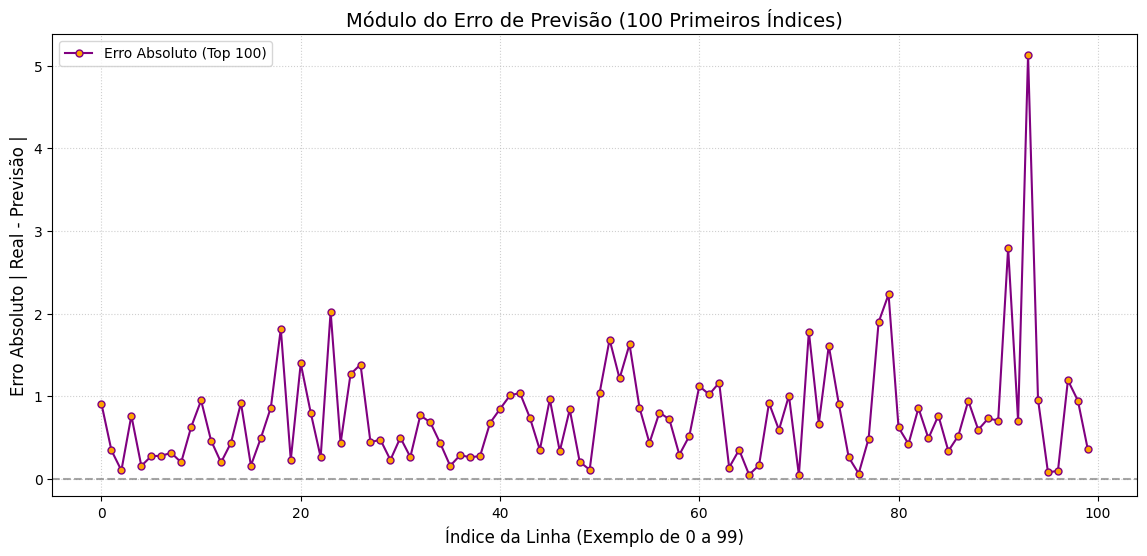

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculando as previsões e o erro absoluto para todo o dataset
y_hat_todos = X @ theta_hat
erros = y - y_hat_todos
erros_absolutos = np.abs(erros)

# 2. SEPARANDO APENAS OS 100 PRIMEIROS CASOS
erros_100_primeiros = erros_absolutos[:100]

# 3. Criando o gráfico
plt.figure(figsize=(14, 6)) # Deixei o gráfico um pouco mais largo (14) para caberem bem os 100 pontos

# Desenhando o gráfico de linhas com pontos
plt.plot(range(len(erros_100_primeiros)), erros_100_primeiros, 
         marker='o',               
         linestyle='-',            
         color='purple',           
         markerfacecolor='orange', 
         markersize=5,             # Deixei o ponto um pouquinho menor para não ficar amontoado
         linewidth=1.5,            
         label='Erro Absoluto (Top 100)')

# Configurações de texto e design
plt.title('Módulo do Erro de Previsão (100 Primeiros Índices)', fontsize=14)
plt.xlabel('Índice da Linha (Exemplo de 0 a 99)', fontsize=12)
plt.ylabel('Erro Absoluto | Real - Previsão |', fontsize=12)

# Linha do zero e grade
plt.axhline(0, color='gray', linestyle='--', alpha=0.7) 
plt.grid(axis='both', linestyle=':', alpha=0.6)
plt.legend()

# Exibe o gráfico
plt.show()